In [19]:
import pandas as pd 
import numpy as np 
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller

In [ ]:
#use this to install whatever other modules
#!pip install statsmodels
#!pip install yfinance

In [20]:
import sys
import yfinance as yf

print(sys.version)
print(yf.__version__)

3.12.2 | packaged by Anaconda, Inc. | (main, Feb 27 2024, 12:57:28) [Clang 14.0.6 ]
1.4.1


In [21]:
prices.columns

MultiIndex([( 'Close',  'KO'),
            ( 'Close', 'PEP'),
            (  'High',  'KO'),
            (  'High', 'PEP'),
            (   'Low',  'KO'),
            (   'Low', 'PEP'),
            (  'Open',  'KO'),
            (  'Open', 'PEP'),
            ('Volume',  'KO'),
            ('Volume', 'PEP')],
           names=['Price', 'Ticker'])

In [27]:
prices = yf.download(["KO", "PEP"], auto_adjust=True, start="2015-01-01", end="2022-01-01")
prices.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker             KO        PEP         KO        PEP         KO        PEP   
Date                                                                           
2015-01-02  29.390251  66.582939  29.571588  67.217461  29.153120  66.307978   
2015-01-05  29.390251  66.082382  29.969130  67.013020  29.348406  66.075330   
2015-01-06  29.613447  65.581787  29.948220  66.709838  29.460011  65.525389   
2015-01-07  29.983082  67.499489  30.066774  67.844957  29.697130  66.575902   
2015-01-08  30.345766  68.726212  30.387614  69.029374  30.059814  68.162186   

Price            Open               Volume           
Ticker             KO        PEP        KO      PEP  
Date                                                 
2015-01-02  29.473944  66.928402   9921100  3545700  
2015-01-05  29.773844  66.589999  26292600  6441000  
2015-01-06  29.578576  66.329121  16897500  6195000  
2015-01-07  29.850566  67.069421  13412300  6526300  
2015-01-08  30.115611  68.204486  21743600  7131600

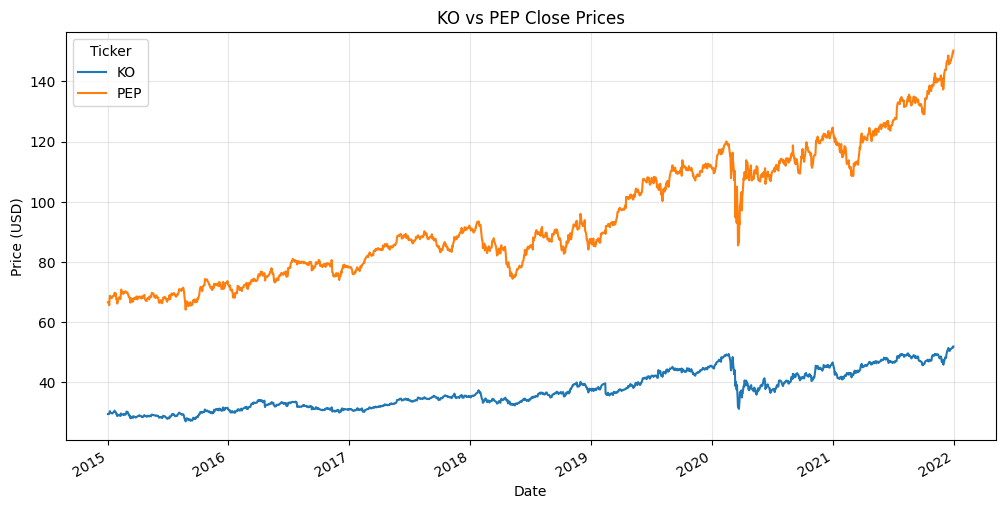

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

# Robustly extract 'Close' prices from the yfinance DataFrame (works with MultiIndex columns)
close = prices['Close']
# Pick KO and PEP if available
cols = [c for c in ['KO', 'PEP'] if c in close.columns]
ax = close[cols].plot(figsize=(12,6), title='KO vs PEP Close Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.grid(alpha=0.3)
plt.show()
    

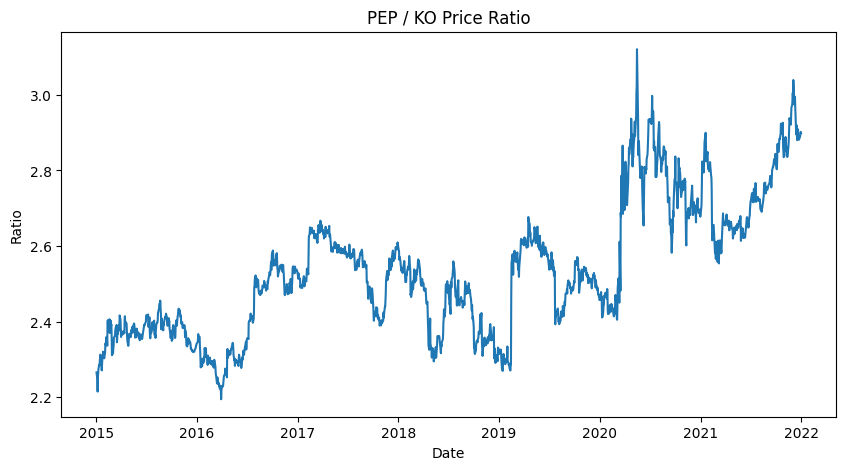

In [29]:
ratio = prices['Close']['PEP'] / prices['Close']['KO']
plt.figure(figsize=(10,5))
plt.plot(ratio)
plt.title("PEP / KO Price Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.show()

In [30]:
corr = prices["Close"]["PEP"].corr(prices["Close"]["KO"])
print(corr)

0.9619258241111182


## Cointegration Test
x_t and y_t are cointegrated, if x_t and y_t are I(1) series and there exists beta such that z_t = x_t - beta * y_t is an I(0) series

Meaning, individually they are x_t and y_t are non stationary but there is some linear combination of them which is stationary (mean reverting).

Cointegration describes a long-term relationship between two (or more) asset prices.
Cointegration can be viewed as a measure of similarity of assets in terms of risk exposure profiles.
The prices of cointegrated assets are tethered due to the stationarity of the spread.

From: https://hudsonthames.org/an-introduction-to-cointegration/

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Step 1: regression
X = sm.add_constant(prices["Close"]["KO"]) #adds an intercept
model = sm.OLS(prices["Close"]["PEP"], X).fit() #runs least squares for regression

# Step 2: residuals
spread = model.resid

# Step 3: ADF test, a test to see if a time series is stationary (mean reverting)
adf_result = adfuller(spread)
print(adf_result[1])  # p-value

Date
2015-01-02   -3.672633
2015-01-05   -4.173190
2015-01-06   -5.380738
2015-01-07   -4.633820
2015-01-08   -4.555867
                ...   
2021-12-27    8.506642
2021-12-28    8.638674
2021-12-29    8.972318
2021-12-30    9.184315
2021-12-31    8.891372
Length: 1763, dtype: float64
0.013000885606606345


In [35]:
model.params

const   -22.835350
KO        3.167408
dtype: float64

In [38]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PEP   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                 2.181e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:38:31   Log-Likelihood:                -5535.9
No. Observations:                1763   AIC:                         1.108e+04
Df Residuals:                    1761   BIC:                         1.109e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.8353      0.805    -28.352      0.0

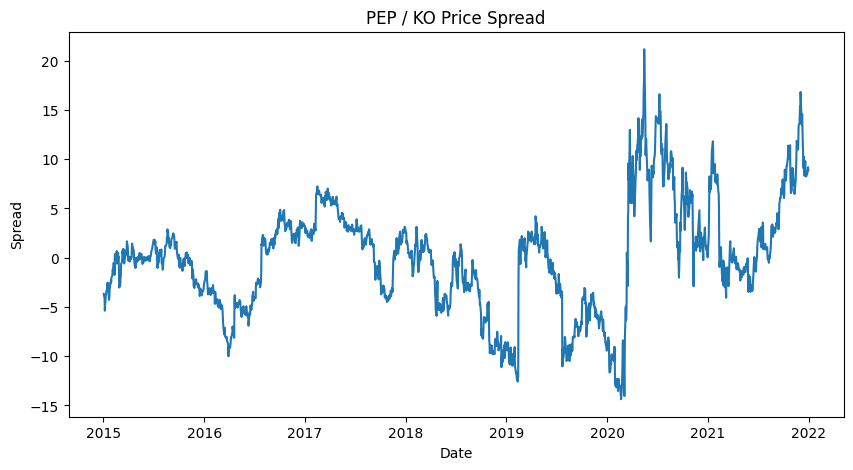

In [36]:
plt.figure(figsize=(10,5))
plt.plot(spread)
plt.title("PEP / KO Price Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.show()